In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/creditcard.csv')
print("Data loaded:", df.shape)

Data loaded: (284807, 31)


In [2]:
# Scale Amount dan Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop kolom asli
df = df.drop(['Amount', 'Time'], axis=1)

# Split features & target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud in train:", y_train.sum())

Train size: (227845, 30)
Test size: (56962, 30)
Fraud in train: 394


In [3]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Setelah SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Sebelum SMOTE: {0: 227451, 1: 394}
Setelah SMOTE: {0: 227451, 1: 227451}


In [4]:
mlflow.set_experiment("fraud-detection")

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        print(f"\nTraining {name}...")
        model.fit(X_train_sm, y_train_sm)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        roc_auc = roc_auc_score(y_test, y_prob)
        
        mlflow.log_param("model", name)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # Fix: tambah trusted types untuk XGBoost
        mlflow.sklearn.log_model(
            model, name,
            skops_trusted_types=[
                "xgboost.core.Booster",
                "xgboost.sklearn.XGBClassifier"
            ]
        )
        
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))


Training LogisticRegression...


2026/07/09 21:07:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


ROC-AUC: 0.9698
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Training RandomForest...


2026/07/09 21:14:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


ROC-AUC: 0.9688
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Training XGBoost...


2026/07/09 21:14:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


ROC-AUC: 0.9745
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [5]:
import joblib
import os

# Simpan model terbaik (XGBoost)
os.makedirs('../models', exist_ok=True)
joblib.dump(models['XGBoost'], '../models/xgboost_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model saved!")

Model saved!


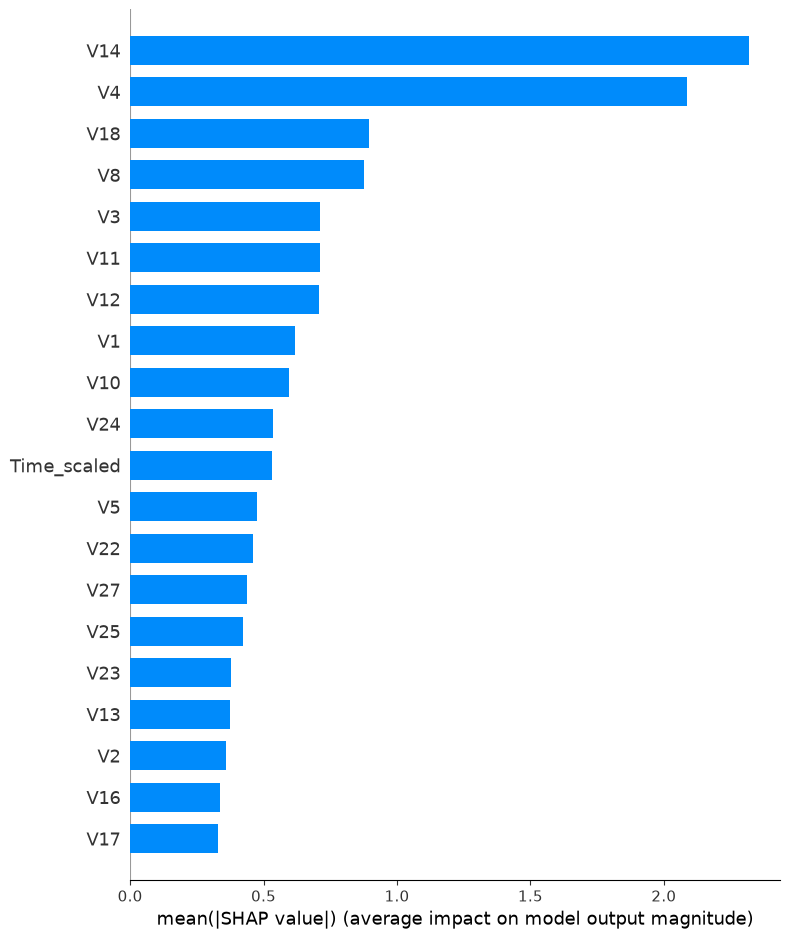

In [6]:
import shap

# Buat SHAP explainer
explainer = shap.TreeExplainer(models['XGBoost'])

# Ambil sample kecil dari test set buat visualisasi
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot — fitur mana yang paling berpengaruh
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

In [7]:
import joblib

# Simpan explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer saved!")

SHAP explainer saved!
